<a href="https://colab.research.google.com/github/satheeshbhukya/GSOC-DEEPLENSE/blob/main/common_task/DeepLense_multiclassification_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/deeplense/dataset.zip"
extract_path = "/content/deeplense_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/deeplense_dataset


This notebook implements a gravitational lensing classifier on the provided dataset.

**Pipeline Overview**

* Load data and build DataFrames for training and evaluation (df_train, df_eval)
* Construct a PyTorch Dataset class
* Define CNN and Transfer Learning model architectures
* Implement ModelHelper class with Loss, Optimizer, Scheduler, and Metric utilities
* Implement Trainer class with fit, evaluate, and run methods
* Execute model training

In [3]:
# importing necessary library
import numpy as np
import pandas as pd
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from tqdm import tqdm
import timm

# importing torch_libraries
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [4]:
class Config:
    learning_rate = 0.0002
    batch_size = 64
    n_classes = 3
    label_col = "label"
    n_epochs = 10
    random_seed = 42
    n_workers = 2
    use_augmentation = False
    weight_decay = 1e-2
    do_train = True
    debug_mode = False
    eval_metric = "roc_auc"
    lr_scheduler = "StepLR"
    optimizer_name = "Adam"
    loss_fn_name = "CrossEntropyLoss"
    grad_clip = 1000
    peak_lr = 4e-4
    warmup_epochs = 1.0
    backbone = "tf_efficientnet_b4_ns"


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
data_1 = np.load('/content/deeplense_dataset/dataset/train/no/10.npy')
data_2 = np.load('/content/deeplense_dataset/dataset/train/no/1.npy')
data_3 = np.load('/content/deeplense_dataset/dataset/train/vort/1.npy')


In [7]:
data_1

array([[[0.01233046, 0.01479655, 0.01849568, ..., 0.00986436,
         0.00616523, 0.01479655],
        [0.01726264, 0.0135635 , 0.01109741, ..., 0.01109741,
         0.01602959, 0.00863132],
        [0.01479655, 0.01726264, 0.01109741, ..., 0.00616523,
         0.01726264, 0.01109741],
        ...,
        [0.01109741, 0.00986436, 0.0135635 , ..., 0.01479655,
         0.01109741, 0.01972873],
        [0.01726264, 0.01233046, 0.01479655, ..., 0.00739827,
         0.00739827, 0.01972873],
        [0.00739827, 0.00986436, 0.01109741, ..., 0.00616523,
         0.01109741, 0.0135635 ]]])

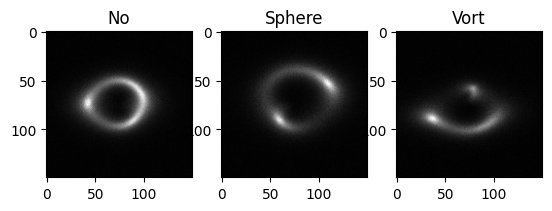

In [8]:
# Plotting the images
data_1 = np.squeeze(data_1)
data_2 = np.squeeze(data_2)
data_3 = np.squeeze(data_3)
plt.subplot(1, 3, 1)
plt.imshow(data_1, cmap="gray")
plt.title("No")
plt.subplot(1, 3, 2)
plt.imshow(data_2, cmap="gray")
plt.title("Sphere")
plt.subplot(1, 3, 3)
plt.title("Vort")
plt.imshow(data_3, cmap="gray")

In [9]:
# path defining

no_train     = os.listdir('/content/deeplense_dataset/dataset/train/no')
sphere_train = os.listdir('/content/deeplense_dataset/dataset/train/sphere')
vort_train   = os.listdir('/content/deeplense_dataset/dataset/train/vort')

no_val       = os.listdir('/content/deeplense_dataset/dataset/val/no')
sphere_val   = os.listdir('/content/deeplense_dataset/dataset/val/sphere')
vort_val     = os.listdir('/content/deeplense_dataset/dataset/val/vort')

In [10]:
# Helper Function to create dataframe for train and validation
def data_helper(dir, d_type='train'):
    df = pd.DataFrame()
    target = []
    data_path = []

    if d_type=='train':
        path_1 = no_train
        path_2 = sphere_train
        path_3 = vort_train
    else:
        path_1 = no_val
        path_2 = sphere_val
        path_3 = vort_val

    for i in range(len(path_1)):
        target.append(0)
        data_path.append(dir+'/no/'+path_1[i])
    for i in range(len(path_2)):
        target.append(1)
        data_path.append(dir+'/sphere/'+path_2[i])
    for i in range(len(path_3)):
        target.append(2)
        data_path.append(dir+'/vort/'+path_3[i])

    df['label'] = target
    df['data_path'] = data_path
    df = df.sample(frac=1)
    return df

In [11]:
train_df = data_helper('/content/deeplense_dataset/dataset/train', d_type='train')
val_df   = data_helper('/content/deeplense_dataset/dataset/val', d_type='val')

In [12]:
# If Debug is set to true and then it reduce the size of data to check the implementation immediatly
if Config.debug_mode==True:
    train_df = train_df[:10]
    val_df = val_df[:10]

In [13]:
# Pytorch dataset creation
class CustomDataset(Dataset):

    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df['data_path']
        image = np.load(image_path.iloc[idx]).astype(np.float32)
        labels = self.df['label'].iloc[idx]
        if self.transform is not None:
            augmented = self.transform(image=image)
            image = augmented['image']
        return torch.tensor(image), torch.tensor(labels)

In [14]:
class AverageMeter:
    """
    Maintains a running average of a scalar metric.
    """

    def __init__(self):
        self.current = 0
        self.mean = 0
        self.total = 0
        self.n = 0

    def reset(self):
        self.current = 0
        self.mean = 0
        self.total = 0
        self.n = 0

    def update(self, value, count=1):
        self.current = value
        self.total += value * count
        self.n += count
        self.mean = self.total / self.n

In [15]:
# Checking dataset
dataa = CustomDataset(train_df)
img, labels = dataa[0]
img.shape

torch.Size([1, 150, 150])

In [16]:
# Custom CNN Model
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(18496, 120)
        self.fc2 = nn.Linear(120, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [17]:
# Pretrained model class using EfficientNet-B0
class PretrainedModel(nn.Module):
    def __init__(self, model_name=Config.backbone, pretrained=False):
        super().__init__()
        self.model_name = model_name
        self.pretrained = pretrained
        self.model = timm.create_model(self.model_name, pretrained=self.pretrained, in_chans=1)
        clsf = self.model.default_cfg['classifier']
        n_features = self.model._modules[clsf].in_features
        self.model._modules[clsf] = nn.Identity()  # Remove the original classifier
        self.fc = nn.Linear(n_features, Config.n_classes)  # Add a new classifier layer

    def forward(self, x):
        x = self.model(x)
        x = self.fc(x)
        return x

In [18]:
# Utility class providing loss, optimizer, scheduler, and metric functions
class ModelHelper:
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

    @property
    def get_loss_fn(self):
        if self.cfg.loss_fn_name == "CrossEntropyLoss":
            return nn.CrossEntropyLoss()
        elif self.cfg.loss_fn_name == "BCEWithLogitsLoss":
            return nn.BCEWithLogitsLoss()

    def compute_metric(self, y_true, y_pred):
        if self.cfg.eval_metric == "accuracy_score":
            return accuracy_score(y_true, y_pred)
        elif self.cfg.eval_metric == "roc_auc":
            return roc_auc_score(y_true, y_pred, multi_class="ovr")

    def build_optimizer(self, model):
        if self.cfg.optimizer_name == 'Adam':
            return torch.optim.Adam(
                model.parameters(), lr=self.cfg.peak_lr,
                weight_decay=self.cfg.weight_decay, amsgrad=False
            )
        if self.cfg.optimizer_name == 'AdamW':
            return torch.optim.AdamW(
                model.parameters(), lr=self.cfg.peak_lr,
                weight_decay=self.cfg.weight_decay
            )

    def build_scheduler(self, optimizer):
        if self.cfg.lr_scheduler == "StepLR":
            return StepLR(optimizer, step_size=2, gamma=0.1)


In [19]:
class Trainer:
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

    def fit_epoch(self, loader, model, loss_fn, optimizer, epoch, scheduler, device):
        model.train()
        epoch_loss = AverageMeter()
        for imgs, targets in tqdm(loader, desc="Training"):
            imgs = imgs.to(device)
            targets = targets.to(device)
            preds = model(imgs)
            bs = imgs.size(0)

            loss = loss_fn(preds, targets)
            epoch_loss.update(loss.item(), bs)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        return epoch_loss.mean

    def eval_epoch(self, loader, model, loss_fn, device):
        model.eval()
        all_preds = []
        epoch_loss = AverageMeter()

        for imgs, targets in tqdm(loader, desc="Evaluating"):
            imgs = imgs.to(device)
            targets = targets.to(device)
            bs = imgs.size(0)

            with torch.no_grad():
                preds = model(imgs)
            loss = loss_fn(preds, targets)
            epoch_loss.update(loss.item(), bs)
            all_preds.append(preds.softmax(1).to('cpu').numpy())

        predictions = np.concatenate(all_preds)
        return epoch_loss.mean, predictions

    def run(self, train_data, eval_data):
        # Build datasets and loaders
        train_ds = CustomDataset(train_data)
        eval_ds = CustomDataset(eval_data)

        train_loader = DataLoader(
            dataset=train_ds, batch_size=self.cfg.batch_size, shuffle=True,
            num_workers=self.cfg.n_workers, pin_memory=True, drop_last=True
        )
        eval_loader = DataLoader(
            dataset=eval_ds, batch_size=self.cfg.batch_size, shuffle=False,
            num_workers=self.cfg.n_workers, pin_memory=True, drop_last=False
        )

        # Initialize model
        model = PretrainedModel(pretrained=True)
        model.to(device)

        helper = ModelHelper(self.cfg)
        optimizer = helper.build_optimizer(model)
        scheduler = helper.build_scheduler(optimizer)
        loss_fn = helper.get_loss_fn

        top_score = -1.0
        results_df = pd.DataFrame()

        for ep in range(self.cfg.n_epochs):
            print(f"Epoch: {ep + 1}")
            train_loss = self.fit_epoch(train_loader, model, loss_fn, optimizer, ep, scheduler, device)
            val_loss, val_preds = self.eval_epoch(eval_loader, model, loss_fn, device)

            true_labels = eval_data['label']
            scheduler.step()

            score = helper.compute_metric(true_labels, val_preds)
            print(f"ROC-AUC Score: {score:.4f}")

            if score > top_score:
                print("New best model found!")
                top_score = score
                print(f"Epoch {ep + 1} — Best Score: {top_score:.4f}")
                torch.save(
                    {
                        'weights': model.state_dict(),
                        'predictions': val_preds,
                        'optimizer_state': optimizer.state_dict(),
                        'scheduler_state': scheduler.state_dict()
                    },
                    f'./{self.cfg.backbone}_checkpoint.pth'
                )

        results_df['true_label'] = true_labels
        results_df['pred_scores'] = list(val_preds)
        return results_df


In [20]:
# main
def main():
    if Config.do_train:
        # train
        train = Trainer(Config)
        df = train.run(train_df, val_df)
    return df

In [21]:
if __name__ == '__main__':
    pred_df = main()

Epoch: 1


Evaluating: 100%|██████████| 118/118 [00:16<00:00,  6.95it/s]


ROC-AUC Score: 0.9274
New best model found!
Epoch 1 — Best Score: 0.9274
Epoch: 2


Evaluating: 100%|██████████| 118/118 [00:15<00:00,  7.76it/s]


ROC-AUC Score: 0.9701
New best model found!
Epoch 2 — Best Score: 0.9701
Epoch: 3


...

ROC-AUC Score: 0.9843
Epoch: 9


Evaluating: 100%|██████████| 118/118 [00:15<00:00,  7.74it/s]


ROC-AUC Score: 0.9844
Epoch: 10


Evaluating: 100%|██████████| 118/118 [00:15<00:00,  7.73it/s]


ROC-AUC Score: 0.9843


In [24]:
# Extract predicted class and max probability for each sample
pred_df

max_probas = []
predicted_classes = []
for scores in pred_df['pred_scores']:
    arr = np.array(scores)
    max_probas.append(arr.max())
    predicted_classes.append(arr.argmax())

pred_df['confidence'] = max_probas
pred_df['pred_label'] = predicted_classes

pred_df.head()


,true_label,pred_scores,confidence,pred_label
3554,1,"[0.0013777224, 0.994327, 0.0042952797]",0.994327,1
5553,2,"[0.00066947023, 0.0016390437, 0.9976915]",0.997692,2
2472,0,"[0.8634289, 0.10066353, 0.035907637]",0.863429,0
880,0,"[0.82390076, 0.1428408, 0.033258516]",0.823901,0
1012,0,"[0.9331087, 0.052424382, 0.014466928]",0.933109,0


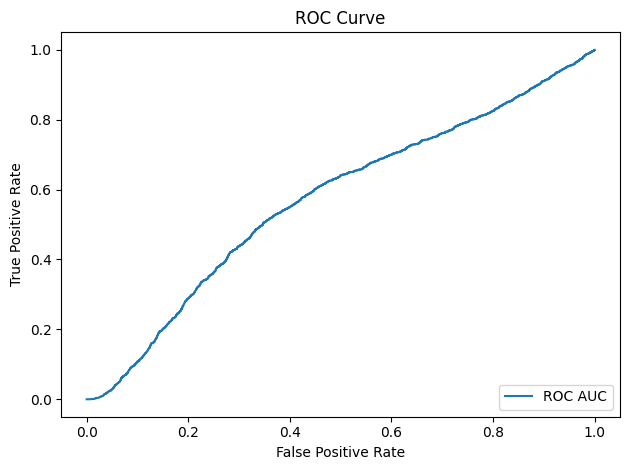

In [25]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(pred_df['true_label'], pred_df['confidence'], pos_label=1)

plt.figure()
plt.plot(fpr, tpr, label='ROC AUC')
plt.title("ROC Curve")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


<Axes: >

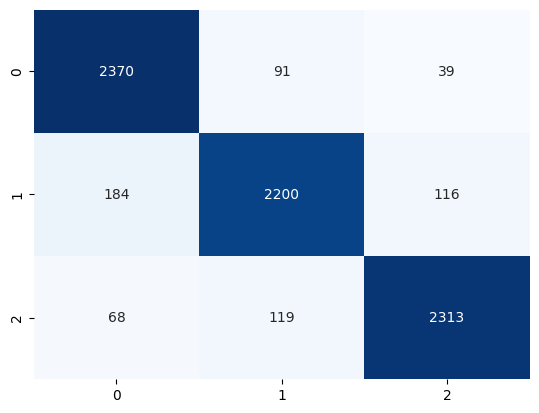

In [29]:
# Plotting Confusion Matrix
m = confusion_matrix(pred_df['true_label'], pred_df['pred_label'])
sns.heatmap(m, cmap='Blues', annot=True, fmt='d', cbar=False)